# WEEK 3 - Linear Regression part 3: linear regression with forward and backward selection, PCR, and PLSR

In [ ]:
# !pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels.api as sm
import networkx as nx

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
#1
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

#2
df_pima = pd.read_csv("pima_indian_diabetes_dataset.csv") 

# Dataset 1 Foward and Backware Feature Selection

Forward Selection

In [5]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score

# --- 1. Prepare data ---
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

# --- 2. Scale and split ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Logistic Regression model ---
log_reg = LogisticRegression(max_iter=5000, solver='lbfgs', multi_class='ovr')

# --- 4. Forward Feature Selection ---
sfs_forward = SequentialFeatureSelector(
    log_reg,
    n_features_to_select='auto',   # or a fixed number, e.g., 8
    direction='forward',           # 👈 forward selection
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs_forward.fit(X_train, y_train)

# --- 5. View selected features ---
selected_forward = X.columns[sfs_forward.get_support()]
print("Forward Selected Features:")
print(selected_forward)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic

Forward Selected Features:
Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HvyAlcoholConsump',
       'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'PhysHlth'],
      dtype='object')


Backward Feature Selection 

In [6]:
# --- Backward Feature Selection ---

X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=5000, solver='lbfgs', multi_class='ovr')

sfs_backward = SequentialFeatureSelector(
    log_reg,
    n_features_to_select='auto',
    direction='backward',          # 👈 backward elimination
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs_backward.fit(X_train, y_train)

selected_backward = X.columns[sfs_backward.get_support()]
print("Backward Selected Features:")
print(selected_backward)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic

Backward Selected Features:
Index(['HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack',
       'PhysActivity', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'Education',
       'Income'],
      dtype='object')


| Method                                   | Use Case                                  | Pros                           | Cons                                               |
| ---------------------------------------- | ----------------------------------------- | ------------------------------ | -------------------------------------------------- |
| **Forward**                              | You want a small, efficient model quickly | Fast, simple                   | Might miss a feature that only matters with others |
| **Backward**                             | You start with many variables             | Comprehensive                  | Slower, can be computationally heavy               |
| **Stepwise**                             | You want a mix                            | Balanced approach              | Can overfit if not cross-validated                 |
| **Regularization (Lasso / Elastic Net)** | You have many correlated predictors       | Automatic shrinkage & sparsity | Doesn’t explicitly test feature subsets            |


comparing and evaluating forward and backware at the same time

In [ ]:
# Forward vs Backward Feature Selection – Logistic Regression

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, roc_auc_score

# --- 1. Prepare data ---
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

# --- 2. Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Define base Logistic Regression model ---
log_reg = LogisticRegression(
    solver='lbfgs', max_iter=5000, multi_class='ovr', random_state=42
)

# Forward Feature Selection

sfs_forward = SequentialFeatureSelector(
    log_reg,
    direction='forward',
    n_features_to_select='auto',   # can also set a number like 10
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs_forward.fit(X_train, y_train)
forward_features = X.columns[sfs_forward.get_support()]

# Train model on selected features
X_train_fwd = X_train[:, sfs_forward.get_support()]
X_test_fwd = X_test[:, sfs_forward.get_support()]
log_reg.fit(X_train_fwd, y_train)
y_pred_fwd = log_reg.predict(X_test_fwd)
y_prob_fwd = log_reg.predict_proba(X_test_fwd)

forward_acc = accuracy_score(y_test, y_pred_fwd)
forward_auc = roc_auc_score(y_test, y_prob_fwd, multi_class='ovr', average='macro')

# Backward Feature Selection

sfs_backward = SequentialFeatureSelector(
    log_reg,
    direction='backward',
    n_features_to_select='auto',
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs_backward.fit(X_train, y_train)
backward_features = X.columns[sfs_backward.get_support()]

# Train model on selected features
X_train_bwd = X_train[:, sfs_backward.get_support()]
X_test_bwd = X_test[:, sfs_backward.get_support()]
log_reg.fit(X_train_bwd, y_train)
y_pred_bwd = log_reg.predict(X_test_bwd)
y_prob_bwd = log_reg.predict_proba(X_test_bwd)

backward_acc = accuracy_score(y_test, y_pred_bwd)
backward_auc = roc_auc_score(y_test, y_prob_bwd, multi_class='ovr', average='macro')

# Results Summary

print("🔹 Forward Selection Features:")
print(list(forward_features))
print(f"Accuracy: {forward_acc:.3f} | AUC: {forward_auc:.3f}\n")

print("🔹 Backward Selection Features:")
print(list(backward_features))
print(f"Accuracy: {backward_acc:.3f} | AUC: {backward_auc:.3f}\n")

# Quick comparison table
results_df = pd.DataFrame({
    'Method': ['Forward', 'Backward'],
    'Selected_Features': [len(forward_features), len(backward_features)],
    'Accuracy': [forward_acc, backward_acc],
    'AUC': [forward_auc, backward_auc]
})

print("🏁 Feature Selection Comparison:")
print(results_df)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic

🔹 Forward Selection Features:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'PhysHlth']
Accuracy: 0.846 | AUC: 0.763

🔹 Backward Selection Features:
['HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'Education', 'Income']
Accuracy: 0.846 | AUC: 0.766

🏁 Feature Selection Comparison:
     Method  Selected_Features  Accuracy       AUC
0   Forward                 10  0.845790  0.763169
1  Backward                 11  0.845829  0.766200


In [10]:
# Forward vs Backward Feature Selection – Logistic Regression - balanced classes

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, roc_auc_score

# --- 1. Prepare data ---
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

# --- 2. Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Define base Logistic Regression model ---
log_reg = LogisticRegression(
    solver='lbfgs', max_iter=5000, multi_class='ovr', random_state=42, class_weight='balanced'
)

# Forward Feature Selection

sfs_forward = SequentialFeatureSelector(
    log_reg,
    direction='forward',
    n_features_to_select='auto',   # can also set a number like 10
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs_forward.fit(X_train, y_train)
forward_features = X.columns[sfs_forward.get_support()]

# Train model on selected features
X_train_fwd = X_train[:, sfs_forward.get_support()]
X_test_fwd = X_test[:, sfs_forward.get_support()]
log_reg.fit(X_train_fwd, y_train)
y_pred_fwd = log_reg.predict(X_test_fwd)
y_prob_fwd = log_reg.predict_proba(X_test_fwd)

forward_acc = accuracy_score(y_test, y_pred_fwd)
forward_auc = roc_auc_score(y_test, y_prob_fwd, multi_class='ovr', average='macro')

# Backward Feature Selection

sfs_backward = SequentialFeatureSelector(
    log_reg,
    direction='backward',
    n_features_to_select='auto',
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs_backward.fit(X_train, y_train)
backward_features = X.columns[sfs_backward.get_support()]

# Train model on selected features
X_train_bwd = X_train[:, sfs_backward.get_support()]
X_test_bwd = X_test[:, sfs_backward.get_support()]
log_reg.fit(X_train_bwd, y_train)
y_pred_bwd = log_reg.predict(X_test_bwd)
y_prob_bwd = log_reg.predict_proba(X_test_bwd)

backward_acc = accuracy_score(y_test, y_pred_bwd)
backward_auc = roc_auc_score(y_test, y_prob_bwd, multi_class='ovr', average='macro')


# Results Summary

print("🔹 Forward Selection Features:")
print(list(forward_features))
print(f"Accuracy: {forward_acc:.3f} | AUC: {forward_auc:.3f}\n")

print("🔹 Backward Selection Features:")
print(list(backward_features))
print(f"Accuracy: {backward_acc:.3f} | AUC: {backward_auc:.3f}\n")

# Quick comparison table
results_df = pd.DataFrame({
    'Method': ['Forward', 'Backward'],
    'Selected_Features': [len(forward_features), len(backward_features)],
    'Accuracy': [forward_acc, backward_acc],
    'AUC': [forward_auc, backward_auc]
})

print("🏁 Feature Selection Comparison:")
print(results_df)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic

🔹 Forward Selection Features:
['CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'Fruits', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'PhysHlth', 'DiffWalk', 'Sex']
Accuracy: 0.727 | AUC: 0.667

🔹 Backward Selection Features:
['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'AnyHealthcare', 'GenHlth', 'MentHlth', 'DiffWalk', 'Income']
Accuracy: 0.692 | AUC: 0.768

🏁 Feature Selection Comparison:
     Method  Selected_Features  Accuracy       AUC
0   Forward                 10  0.727472  0.667406
1  Backward                 11  0.692487  0.767915


| Method       | Features Selected | Accuracy |  AUC  |
| :----------- | :---------------: | :------: | :---: |
| **Forward**  |         10        |   0.727  | 0.667 |
| **Backward** |         11        |   0.692  | 0.768 |


Foward feature selection selected 10 features: 'CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'Fruits', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'PhysHlth', 'DiffWalk', 'Sex'. Backward feature selection chose 11 features: 'HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'AnyHealthcare', 'GenHlth', 'MentHlth', 'DiffWalk', 'Income'.





PCR

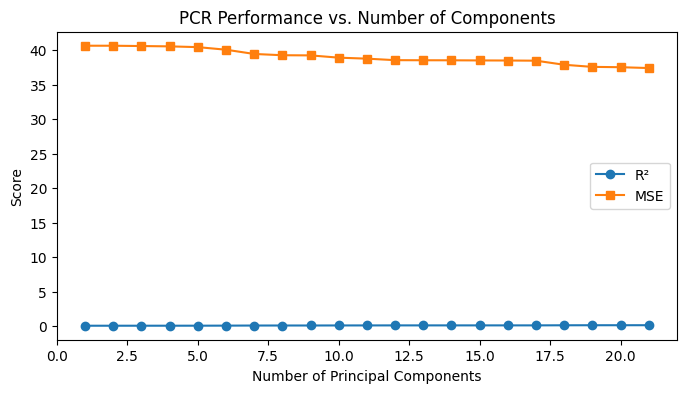

Optimal number of components: 21
Best R²: 0.139
Best MSE: 37.432

Final Model Performance:
R²: 0.139
MSE: 37.432


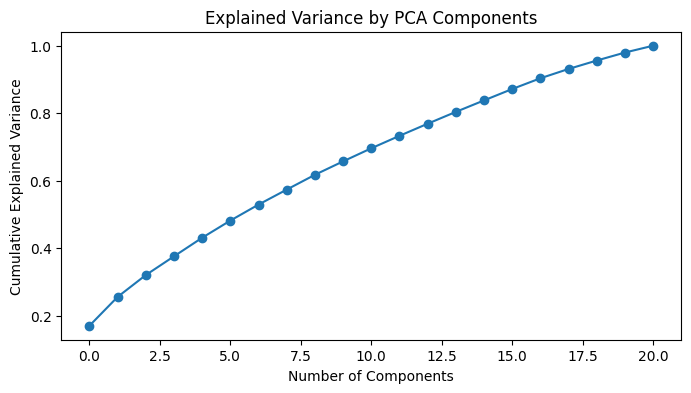

In [11]:
# Principal Component Regression (PCR) - Data Set 1 - useing BMI as the target 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. Prepare Data ---
# predict BMI using all other features

X = df.drop(columns=['BMI'])  # predictors
y = df['BMI']                 # target (continuous)

# --- 2. Scale Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- 4. Try different numbers of principal components ---
n_components = np.arange(1, X.shape[1] + 1)
r2_scores = []
mse_scores = []

for n in n_components:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))

# --- 5. Plot performance vs components ---
plt.figure(figsize=(8,4))
plt.plot(n_components, r2_scores, marker='o', label='R²')
plt.plot(n_components, mse_scores, marker='s', label='MSE')
plt.xlabel('Number of Principal Components')
plt.ylabel('Score')
plt.title('PCR Performance vs. Number of Components')
plt.legend()
plt.show()

# --- 6. Choose best number of components ---
best_n = n_components[np.argmax(r2_scores)]
print(f"Optimal number of components: {best_n}")
print(f"Best R²: {max(r2_scores):.3f}")
print(f"Best MSE: {min(mse_scores):.3f}")

# --- 7. Refit with best number of components ---
pca = PCA(n_components=best_n)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

final_model = LinearRegression()
final_model.fit(X_train_pca, y_train)
y_pred_final = final_model.predict(X_test_pca)

# --- 8. Final evaluation ---
print("\nFinal Model Performance:")
print(f"R²: {r2_score(y_test, y_pred_final):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_final):.3f}")

# --- 9. Optional: Explained variance plot ---
plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.show()


PCR found the optimal number of components to be 21, which means the model needed a lot of components to full represent the relationship between the data and BMI. THerefore there are mamy weak signals spread across the dataset instead of a few strong predictors. The R2 is quite low at 0.139, meaning it explains only 13.9% of the variance in BMI. However the RMSE is moderate at 37.432.Overall there is . Since this dataset is focused on diabetes health factors, it makes sense that we are not able to predict BMI with a lot of accuracy. There are many more factors that contribute to BMI that are captured in this dataset. 

"The PLS Regression model using 21 components explained only 13.9% of the variation in BMI (R² = 0.139) with a mean squared error of 37.43, suggesting that BMI is only weakly related to the measured predictors and likely influenced by additional unobserved factors or nonlinear relationships."

PLSR - dataset 1

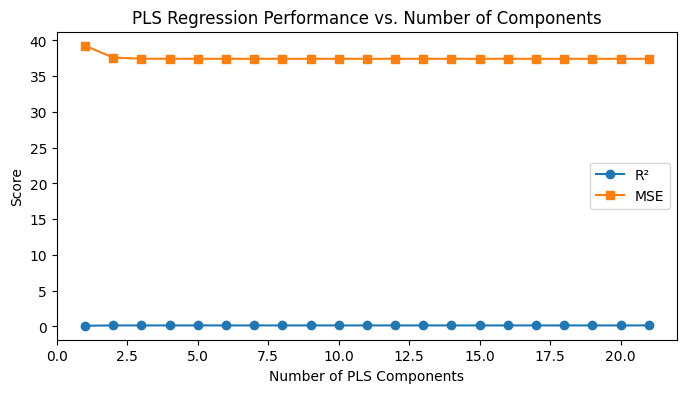

Optimal number of components: 6
Best R²: 0.139
Best MSE: 37.432

Final Model Performance:
R²: 0.139
MSE: 37.432

Component Importance (VIP Approximation):
   Component         VIP
0          1  782.398388
1          2  452.481109
2          3  395.274379
3          4  434.643354
4          5  420.008085
5          6  442.906453


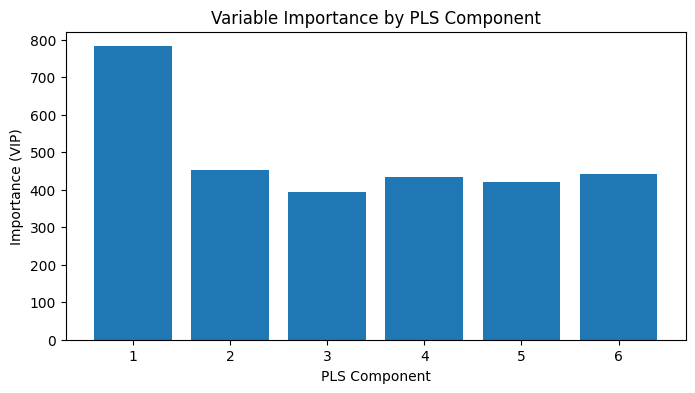

In [18]:
# --- Partial Least Squares Regression (PLSR) --- dataset 1 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. Prepare data ---
X = df.drop(columns=['BMI'])
y = df['BMI']

# --- 2. Scale predictors ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- 4. Tune number of components ---
n_components = np.arange(1, X.shape[1] + 1)
r2_scores = []
mse_scores = []

for n in n_components:
    pls = PLSRegression(n_components=n)
    pls.fit(X_train, y_train)
    y_pred = pls.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))

# --- 5. Plot performance ---
plt.figure(figsize=(8,4))
plt.plot(n_components, r2_scores, marker='o', label='R²')
plt.plot(n_components, mse_scores, marker='s', label='MSE')
plt.xlabel('Number of PLS Components')
plt.ylabel('Score')
plt.title('PLS Regression Performance vs. Number of Components')
plt.legend()
plt.show()

# --- 6. Optimal number of components ---
best_n = n_components[np.argmax(r2_scores)]
print(f"Optimal number of components: {best_n}")
print(f"Best R²: {max(r2_scores):.3f}")
print(f"Best MSE: {min(mse_scores):.3f}")

# --- 7. Refit final model ---
pls_final = PLSRegression(n_components=best_n)
pls_final.fit(X_train, y_train)
y_pred_final = pls_final.predict(X_test)

print("\nFinal Model Performance:")
print(f"R²: {r2_score(y_test, y_pred_final):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_final):.3f}")

# --- 8. Inspect variable importance (VIP approximation) ---
vip_scores = np.sqrt(np.sum(pls_final.x_scores_**2, axis=0))
vip_df = pd.DataFrame({'Component': np.arange(1, best_n+1), 'VIP': vip_scores})
print("\nComponent Importance (VIP Approximation):")
print(vip_df)

plt.figure(figsize=(8,4))
plt.bar(np.arange(1, best_n+1), vip_scores)
plt.xlabel('PLS Component')
plt.ylabel('Importance (VIP)')
plt.title('Variable Importance by PLS Component')
plt.show()


The PLSR model identified the optimal number of components to be 6, much less than PCR. the R2 is the same at 0.139 Which is relatively low. Overall most of the variation in BMI is coming from an external factor not measured in this dataset. I also measured the approximate Variable Importance in Projection (VIP) score. The VIP for componenet 1 was 782.4 while the VIP for component 2 through 6 was about 400. Therefore the first component is driving the majority of the models predictive power. 

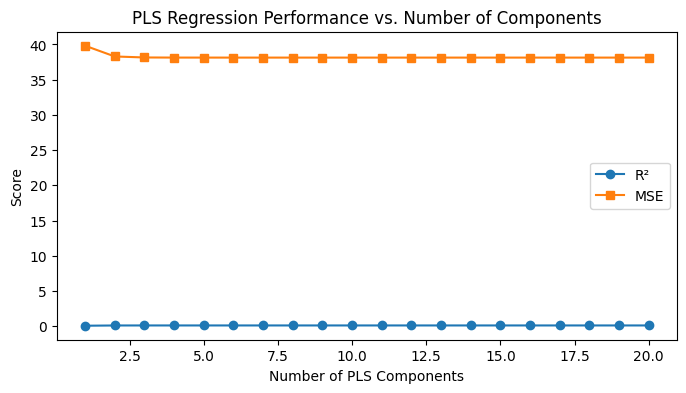

Optimal number of components: 6
Best R²: 0.123
Best MSE: 38.129

Final Model Performance:
R²: 0.123
MSE: 38.129

Component Importance (VIP Approximation):
   Component         VIP
0          1  765.915196
1          2  433.706648
2          3  413.540115
3          4  467.460568
4          5  454.261738
5          6  421.127022


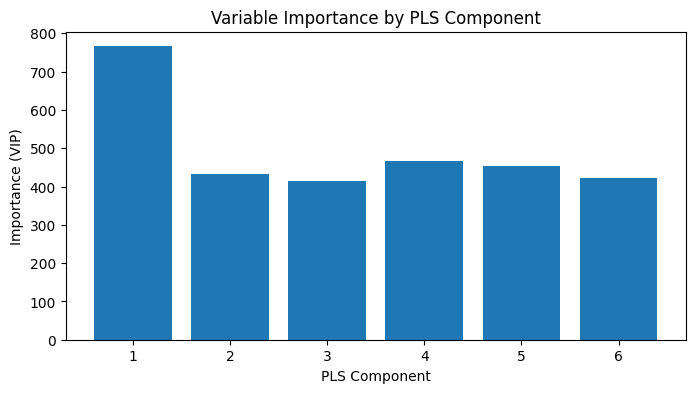

In [ ]:
# --- Partial Least Squares Regression (PLSR) --- dataset 1 - deleted diabetes column 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. Prepare data ---
X = df.drop(columns=['BMI', 'Diabetes_012'])
y = df['BMI']

# --- 2. Scale predictors ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- 4. Tune number of components ---
n_components = np.arange(1, X.shape[1] + 1)
r2_scores = []
mse_scores = []

for n in n_components:
    pls = PLSRegression(n_components=n)
    pls.fit(X_train, y_train)
    y_pred = pls.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))

# --- 5. Plot performance ---
plt.figure(figsize=(8,4))
plt.plot(n_components, r2_scores, marker='o', label='R²')
plt.plot(n_components, mse_scores, marker='s', label='MSE')
plt.xlabel('Number of PLS Components')
plt.ylabel('Score')
plt.title('PLS Regression Performance vs. Number of Components')
plt.legend()
plt.show()

# --- 6. Optimal number of components ---
best_n = n_components[np.argmax(r2_scores)]
print(f"Optimal number of components: {best_n}")
print(f"Best R²: {max(r2_scores):.3f}")
print(f"Best MSE: {min(mse_scores):.3f}")

# --- 7. Refit final model ---
pls_final = PLSRegression(n_components=best_n)
pls_final.fit(X_train, y_train)
y_pred_final = pls_final.predict(X_test)

print("\nFinal Model Performance:")
print(f"R²: {r2_score(y_test, y_pred_final):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_final):.3f}")

# --- 8. Inspect variable importance (VIP approximation) ---
vip_scores = np.sqrt(np.sum(pls_final.x_scores_**2, axis=0))
vip_df = pd.DataFrame({'Component': np.arange(1, best_n+1), 'VIP': vip_scores})
print("\nComponent Importance (VIP Approximation):")
print(vip_df)

plt.figure(figsize=(8,4))
plt.bar(np.arange(1, best_n+1), vip_scores)
plt.xlabel('PLS Component')
plt.ylabel('Importance (VIP)')
plt.title('Variable Importance by PLS Component')
plt.show()


# Dataset 2 Pima

Forward and Backward Feature selection comparison 

In [9]:
# Forward vs Backward Feature Selection – Logistic Regression

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, roc_auc_score

# --- 1. Prepare data ---
X = df_pima.drop(columns=['Outcome'])
y = df_pima['Outcome']

# --- 2. Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Define base Logistic Regression model ---
log_reg = LogisticRegression(
    solver='lbfgs', max_iter=5000, multi_class='ovr', random_state=42,  class_weight='balanced',
)

# Forward Feature Selection

sfs_forward = SequentialFeatureSelector(
    log_reg,
    direction='forward',
    n_features_to_select='auto',   # can also set a number like 10
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs_forward.fit(X_train, y_train)
forward_features = X.columns[sfs_forward.get_support()]

# Train model on selected features
X_train_fwd = X_train[:, sfs_forward.get_support()]
X_test_fwd = X_test[:, sfs_forward.get_support()]
log_reg.fit(X_train_fwd, y_train)
y_pred_fwd = log_reg.predict(X_test_fwd)
y_prob_fwd = log_reg.predict_proba(X_test_fwd)

forward_acc = accuracy_score(y_test, y_pred_fwd)
forward_auc = roc_auc_score(y_test, y_prob_fwd[:, 1])

# Backward Feature Selection

sfs_backward = SequentialFeatureSelector(
    log_reg,
    direction='backward',
    n_features_to_select='auto',
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs_backward.fit(X_train, y_train)
backward_features = X.columns[sfs_backward.get_support()]

# Train model on selected features
X_train_bwd = X_train[:, sfs_backward.get_support()]
X_test_bwd = X_test[:, sfs_backward.get_support()]
log_reg.fit(X_train_bwd, y_train)
y_pred_bwd = log_reg.predict(X_test_bwd)
y_prob_bwd = log_reg.predict_proba(X_test_bwd)

backward_acc = accuracy_score(y_test, y_pred_bwd)
backward_auc = roc_auc_score(y_test, y_prob_bwd[:, 1])

# Results Summary

print("🔹 Forward Selection Features:")
print(list(forward_features))
print(f"Accuracy: {forward_acc:.3f} | AUC: {forward_auc:.3f}\n")

print("🔹 Backward Selection Features:")
print(list(backward_features))
print(f"Accuracy: {backward_acc:.3f} | AUC: {backward_auc:.3f}\n")

# Quick comparison table
results_df = pd.DataFrame({
    'Method': ['Forward', 'Backward'],
    'Selected_Features': [len(forward_features), len(backward_features)],
    'Accuracy': [forward_acc, backward_acc],
    'AUC': [forward_auc, backward_auc]
})

print("🏁 Feature Selection Comparison:")
print(results_df)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic

🔹 Forward Selection Features:
['Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
Accuracy: 0.701 | AUC: 0.794

🔹 Backward Selection Features:
['Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
Accuracy: 0.701 | AUC: 0.794

🏁 Feature Selection Comparison:
     Method  Selected_Features  Accuracy       AUC
0   Forward                  4  0.701299  0.793704
1  Backward                  4  0.701299  0.793704


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic

Both forward and backward feature selection chose the same 4 features: 'Glucose', 'Insulin', 'BMI', and 'DiabetesPedigreeFunction'. They also both achieved the same accuracy of 0.70, and AUC of 0.79. This means that the model is stable and generalizing well and not overfitting. No matter which way the features are selected, the same four variables explain almost all of the predictive signal. These four features have the most clinical significance in the medical setting for predicting diabetes as well. This gives the model more credibility. I wonder why the lasso, ridge and elastic net models did not consider Insulin to be a top feature.  


| Metric       | Use it when...                                       | What it tells you                                       |
| ------------ | ---------------------------------------------------- | ------------------------------------------------------- |
| **Accuracy** | Classes fairly balanced                              | Overall correctness                                     |
| **AUC**      | You want to measure ranking ability (threshold-free) | How well the model separates diabetics vs non-diabetics |
| **F1-score** | Classes imbalanced, and recall matters more          | Balance of precision & recall for diabetics             |


PCR for BMI 

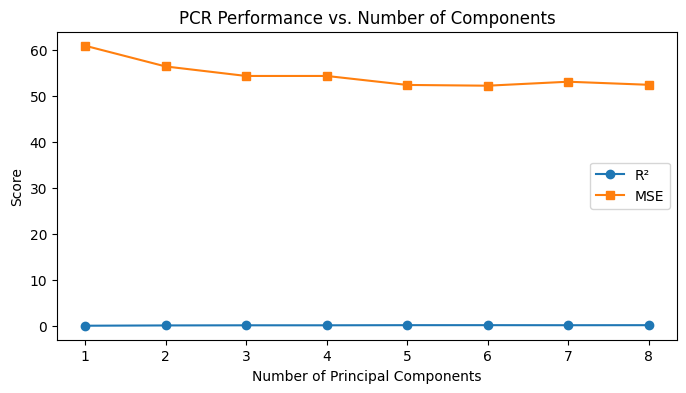

Optimal number of components: 6
Best R²: 0.265
Best MSE: 52.263

Final Model Performance:
R²: 0.265
MSE: 52.263


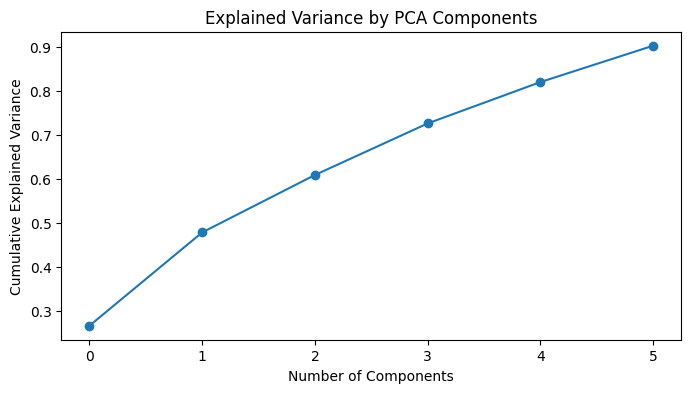

In [12]:
# Principal Component Regression (PCR) - Data Set 2 - useing BMI as the target 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. Prepare Data ---
# predict BMI using all other features

X = df_pima.drop(columns=['BMI'])  # predictors
y = df_pima['BMI']                 # target (continuous)

# --- 2. Scale Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- 4. Try different numbers of principal components ---
n_components = np.arange(1, X.shape[1] + 1)
r2_scores = []
mse_scores = []

for n in n_components:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))

# --- 5. Plot performance vs components ---
plt.figure(figsize=(8,4))
plt.plot(n_components, r2_scores, marker='o', label='R²')
plt.plot(n_components, mse_scores, marker='s', label='MSE')
plt.xlabel('Number of Principal Components')
plt.ylabel('Score')
plt.title('PCR Performance vs. Number of Components')
plt.legend()
plt.show()

# --- 6. Choose best number of components ---
best_n = n_components[np.argmax(r2_scores)]
print(f"Optimal number of components: {best_n}")
print(f"Best R²: {max(r2_scores):.3f}")
print(f"Best MSE: {min(mse_scores):.3f}")

# --- 7. Refit with best number of components ---
pca = PCA(n_components=best_n)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

final_model = LinearRegression()
final_model.fit(X_train_pca, y_train)
y_pred_final = final_model.predict(X_test_pca)

# --- 8. Final evaluation ---
print("\nFinal Model Performance:")
print(f"R²: {r2_score(y_test, y_pred_final):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_final):.3f}")

# --- 9. Optional: Explained variance plot ---
plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.show()


The PCR found that using 6 componenets is optimal. Using 6 principal components explains about 26.5% of the variation in BMI, based on the R2 value. Therfore most of the variation in BMI remains unexplained. The MSE in orange decreases slightly as the number of components increases, but then flattens out around 52. Overall this tells us that predictors have a limited linear relationship with BMI, and logistic regression is a better choice for this dataset.

"“The PCR model using six principal components explained approximately 26.5% of the variation in BMI (R² = 0.265), with diminishing returns beyond six components. While PCA captured 90% of the predictor variance, this variance only modestly related to BMI, suggesting that BMI is influenced by additional unmeasured factors.”"

PSLR - Dataset 2 - BMI as the target

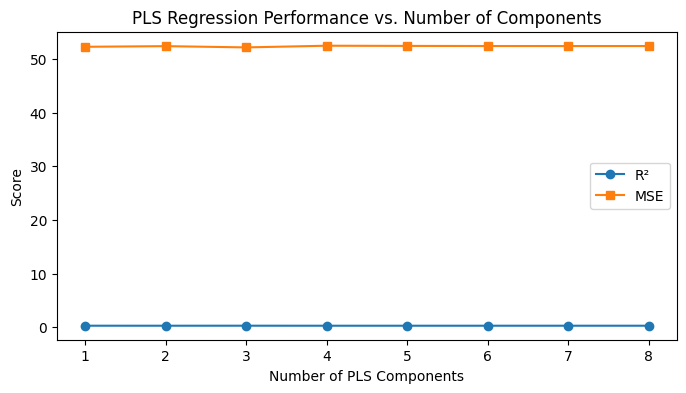

Optimal number of components: 3
Best R²: 0.266
Best MSE: 52.205

Final Model Performance:
R²: 0.266
MSE: 52.205

Component Importance (VIP Approximation):
   Component        VIP
0          1  32.845280
1          2  24.328705
2          3  28.692945


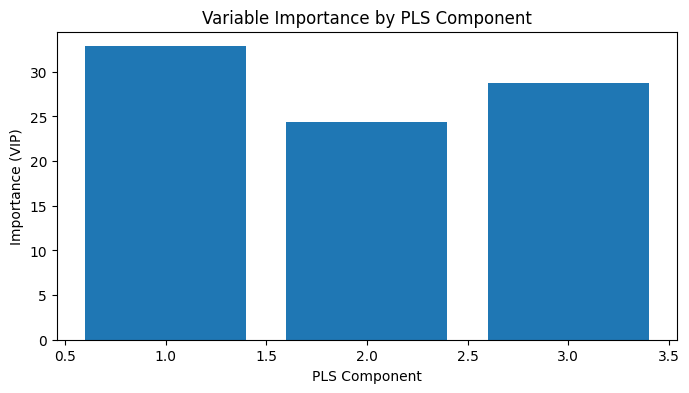

In [16]:
# --- Partial Least Squares Regression (PLSR) --- dataset 2 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. Prepare data ---
X = df_pima.drop(columns=['BMI'])
y = df_pima['BMI']

# --- 2. Scale predictors ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- 4. Tune number of components ---
n_components = np.arange(1, X.shape[1] + 1)
r2_scores = []
mse_scores = []

for n in n_components:
    pls = PLSRegression(n_components=n)
    pls.fit(X_train, y_train)
    y_pred = pls.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))

# --- 5. Plot performance ---
plt.figure(figsize=(8,4))
plt.plot(n_components, r2_scores, marker='o', label='R²')
plt.plot(n_components, mse_scores, marker='s', label='MSE')
plt.xlabel('Number of PLS Components')
plt.ylabel('Score')
plt.title('PLS Regression Performance vs. Number of Components')
plt.legend()
plt.show()

# --- 6. Optimal number of components ---
best_n = n_components[np.argmax(r2_scores)]
print(f"Optimal number of components: {best_n}")
print(f"Best R²: {max(r2_scores):.3f}")
print(f"Best MSE: {min(mse_scores):.3f}")

# --- 7. Refit final model ---
pls_final = PLSRegression(n_components=best_n)
pls_final.fit(X_train, y_train)
y_pred_final = pls_final.predict(X_test)

print("\nFinal Model Performance:")
print(f"R²: {r2_score(y_test, y_pred_final):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_final):.3f}")

# --- 8. Inspect variable importance (VIP approximation) ---
vip_scores = np.sqrt(np.sum(pls_final.x_scores_**2, axis=0))
vip_df = pd.DataFrame({'Component': np.arange(1, best_n+1), 'VIP': vip_scores})
print("\nComponent Importance (VIP Approximation):")
print(vip_df)

plt.figure(figsize=(8,4))
plt.bar(np.arange(1, best_n+1), vip_scores)
plt.xlabel('PLS Component')
plt.ylabel('Importance (VIP)')
plt.title('Variable Importance by PLS Component')
plt.show()


PLSR found the optimal number of components to be 3, but had similar performance as PCR with an R2 of 0.27. Therefor this is a simpler more efficient model since it uses less features. The average mean squared error is also similar to PCR at 52.205. Overall PLSR is more efficient than PCR becuase it forms components that more directly capture the covariance between ...? 

"PLS is more efficient than PCR because it forms components that directly maximize the covariance between predictors (X) and the target (Y).

Whereas PCR just compresses X, PLSR compresses X in a way that helps predict Y."

--> Insert reference about why pcl is better 

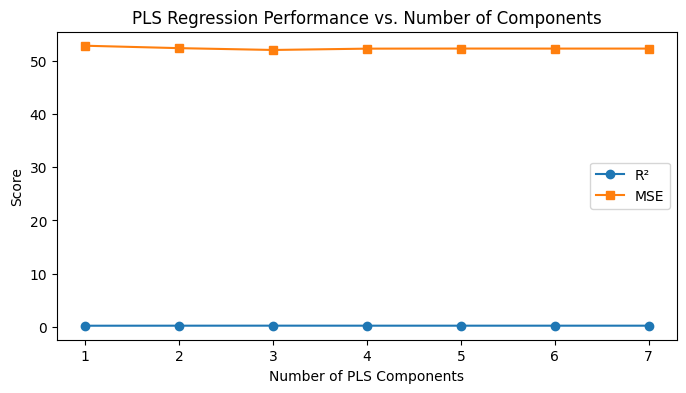

Optimal number of components: 3
Best R²: 0.269
Best MSE: 51.983

Final Model Performance:
R²: 0.269
MSE: 51.983

Component Importance (VIP Approximation):
   Component        VIP
0          1  31.555848
1          2  20.676746
2          3  24.464923


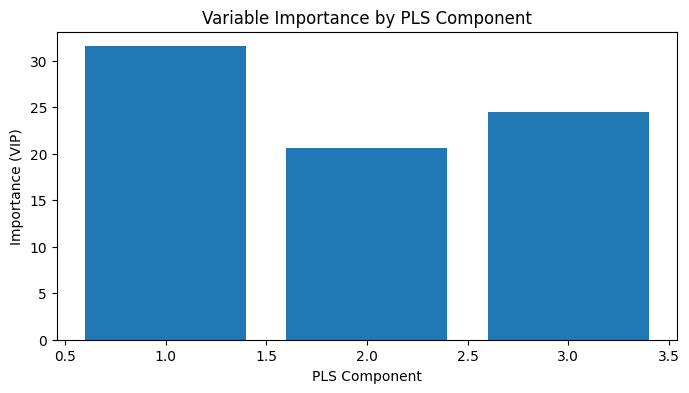

In [17]:
# --- Partial Least Squares Regression (PLSR) --- dataset 2 - dropped Outcome column 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. Prepare data ---
X = df_pima.drop(columns=['BMI', 'Outcome'])
y = df_pima['BMI']

# --- 2. Scale predictors ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- 4. Tune number of components ---
n_components = np.arange(1, X.shape[1] + 1)
r2_scores = []
mse_scores = []

for n in n_components:
    pls = PLSRegression(n_components=n)
    pls.fit(X_train, y_train)
    y_pred = pls.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))

# --- 5. Plot performance ---
plt.figure(figsize=(8,4))
plt.plot(n_components, r2_scores, marker='o', label='R²')
plt.plot(n_components, mse_scores, marker='s', label='MSE')
plt.xlabel('Number of PLS Components')
plt.ylabel('Score')
plt.title('PLS Regression Performance vs. Number of Components')
plt.legend()
plt.show()

# --- 6. Optimal number of components ---
best_n = n_components[np.argmax(r2_scores)]
print(f"Optimal number of components: {best_n}")
print(f"Best R²: {max(r2_scores):.3f}")
print(f"Best MSE: {min(mse_scores):.3f}")

# --- 7. Refit final model ---
pls_final = PLSRegression(n_components=best_n)
pls_final.fit(X_train, y_train)
y_pred_final = pls_final.predict(X_test)

print("\nFinal Model Performance:")
print(f"R²: {r2_score(y_test, y_pred_final):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_final):.3f}")

# --- 8. Inspect variable importance (VIP approximation) ---
vip_scores = np.sqrt(np.sum(pls_final.x_scores_**2, axis=0))
vip_df = pd.DataFrame({'Component': np.arange(1, best_n+1), 'VIP': vip_scores})
print("\nComponent Importance (VIP Approximation):")
print(vip_df)

plt.figure(figsize=(8,4))
plt.bar(np.arange(1, best_n+1), vip_scores)
plt.xlabel('PLS Component')
plt.ylabel('Importance (VIP)')
plt.title('Variable Importance by PLS Component')
plt.show()
